# 02 · Baseline e política adaptativa (Multi-Armed Bandit)

**Datathon MLET · Fase 05**

Entrada: `data/processed/train.parquet` (gerado pelo notebook `01_eda`).

## O problema da avaliação offline

A base registra, para cada cliente, **um** braço (canal + dia) e o resultado. Nunca vemos o que teria acontecido se o banco tivesse ligado em outro dia. Um bandit, porém, precisa de resposta para qualquer braço que escolha.

A solução é um **simulador**: um modelo estima P(conversão | contexto do cliente, braço) a partir dos dados reais. Na simulação, a política escolhe um braço e a recompensa é sorteada com essa probabilidade. Assim todos os braços recebem retorno e todas as políticas são comparadas nos mesmos clientes. A limitação é que a resposta para braços não observados é uma extrapolação do modelo, e por isso validamos o modelo antes de usá-lo.

Organização: (1) construir e validar o simulador, (2) baselines, (3) Thompson Sampling e Epsilon-Greedy, (4) conclusões.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve

from datathon.data import load_processed, ARMS, CONTEXT_NUM, CONTEXT_CAT
from datathon.reward_model import FEATURES, REWARD_MODEL_PARAMS, fit_reward_model, predict_all_arms

ROOT = Path.cwd().parent
MODELS = ROOT / "models"
sns.set_theme(style="whitegrid")
SEED = 42

df = load_processed("train")
print(df.shape, "| braços:", ARMS)

(28645, 22) | braços: ['cellular_mon', 'cellular_tue', 'cellular_wed', 'cellular_thu', 'cellular_fri', 'telephone_mon', 'telephone_tue', 'telephone_wed', 'telephone_thu', 'telephone_fri']


## 1. O simulador: modelo de recompensa

### Por que gradient boosting e não regressão logística

Testamos os dois. Ambos alcançam AUC ≈ 0,79. A diferença está em **como** eles enxergam os braços:

- A regressão logística, sem termos de interação, soma o efeito do braço ao efeito do contexto. Resultado: o melhor braço é **o mesmo para 100% dos clientes** (`cellular_wed`). Num mundo assim, um bandit contextual não tem o que personalizar.
- O gradient boosting captura interações contexto × braço. O melhor braço passa a variar: ≈52% dos clientes têm `cellular_wed` como melhor, ≈16% `telephone_tue`, e assim por diante.

Como o simulador é o "mundo" em que as políticas serão testadas, ele precisa refletir heterogeneidade entre clientes. Escolhemos o boosting, e registramos que **os resultados do bandit contextual dependem dessa escolha** (limitação documentada).

### Validação em hold-out

Antes de usar o modelo como simulador, medimos sua qualidade em 30% dos dados que ele não viu. Duas métricas:

- **AUC**: capacidade de ordenar quem converte mais. 
- **Brier e curva de calibração**: se o modelo diz 20%, converte 20% das vezes? Para um simulador que **sorteia** recompensas, calibração importa mais que AUC.

AUC hold-out:   0.789
Brier hold-out: 0.0794  (referência: prever sempre a média = 0.1015)


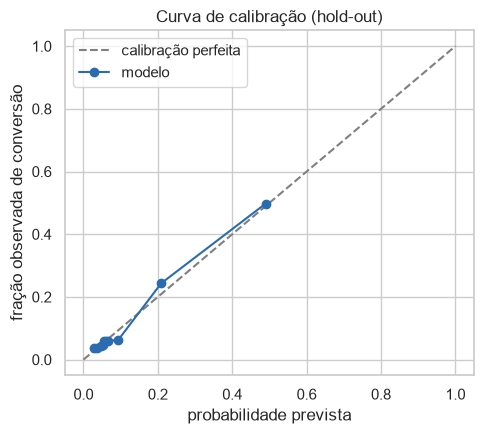

In [2]:
X, y = df[FEATURES], df["reward"]
X_tr, X_ho, y_tr, y_ho = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)

rm_holdout = fit_reward_model(pd.concat([X_tr, y_tr], axis=1))
p_ho = rm_holdout.predict_proba(X_ho)[:, 1]

auc = roc_auc_score(y_ho, p_ho)
brier = brier_score_loss(y_ho, p_ho)
print(f"AUC hold-out:   {auc:.3f}")
print(f"Brier hold-out: {brier:.4f}  (referência: prever sempre a média = {brier_score_loss(y_ho, np.full(len(y_ho), y_tr.mean())):.4f})")

frac_pos, mean_pred = calibration_curve(y_ho, p_ho, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="calibração perfeita")
ax.plot(mean_pred, frac_pos, marker="o", color="#2b6cb0", label="modelo")
ax.set_xlabel("probabilidade prevista"); ax.set_ylabel("fração observada de conversão")
ax.set_title("Curva de calibração (hold-out)"); ax.legend()
plt.tight_layout()

A curva acompanha a diagonal: quando o modelo diz 30%, cerca de 30% convertem. O Brier fica bem abaixo do de "prever sempre a média". O simulador é confiável para sortear recompensas.

### Treino final e matriz de recompensas

Validado, treinamos o modelo em **toda** a base (é o mundo simulado) e calculamos, para cada cliente, a probabilidade de conversão em cada um dos 10 braços. Essa matriz `P` (28.645 × 10) é tudo que a simulação precisa.

In [3]:
reward_model = fit_reward_model(df)
P = predict_all_arms(reward_model, df)          # shape (n_clientes, 10)
print("P:", P.shape)

import joblib
MODELS.mkdir(exist_ok=True)
joblib.dump(reward_model, MODELS / "reward_model.joblib")
np.save(MODELS / "P_matrix.npy", P)

p_media = pd.Series(P.mean(0), index=ARMS).sort_values(ascending=False)
print("\nP(conversão) média por braço no simulador (%):")
print((100 * p_media).round(2).to_string())

P: (28645, 10)

P(conversão) média por braço no simulador (%):
cellular_wed     12.67
cellular_tue     12.51
cellular_thu     11.78
cellular_fri     11.40
cellular_mon     11.10
telephone_fri    10.77
telephone_tue    10.73
telephone_wed    10.70
telephone_thu     9.68
telephone_mon     7.57


**Observação importante.** Na EDA, celular convertia 15% e telefone 5%. No simulador, que controla pelo contexto (inclusive euribor e mês), a diferença encolhe bastante. Confirma o que suspeitávamos: boa parte da vantagem do celular era **época**, não canal. É o tipo de ajuste que um modelo contextual faz e uma tabela de médias não.

Ganho médio de P(conversão) ao escolher o melhor braço de cada cliente, vs. sempre cellular_tue: +1.34 pontos percentuais
Teto teórico (oráculo que sempre acerta o melhor braço): 13.85% de conversão


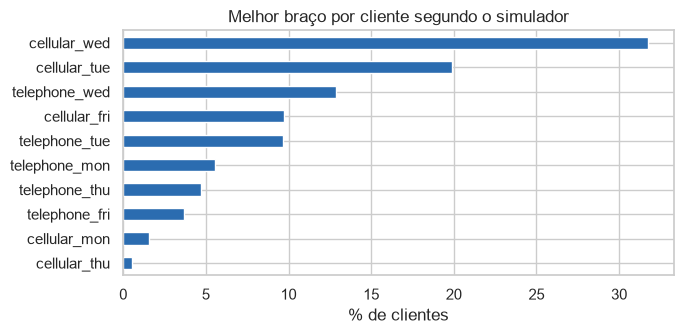

In [4]:
# Heterogeneidade: o melhor braço varia por cliente?
melhor = pd.Series(np.array(ARMS)[P.argmax(1)]).value_counts(normalize=True)
ganho = P.max(1) - P[:, ARMS.index("cellular_tue")]

fig, ax = plt.subplots(figsize=(7, 3.5))
(100 * melhor).plot.barh(ax=ax, color="#2b6cb0")
ax.set_xlabel("% de clientes"); ax.set_title("Melhor braço por cliente segundo o simulador")
ax.invert_yaxis(); plt.tight_layout()

print(f"Ganho médio de P(conversão) ao escolher o melhor braço de cada cliente, "
      f"vs. sempre cellular_tue: +{100 * ganho.mean():.2f} pontos percentuais")
print(f"Teto teórico (oráculo que sempre acerta o melhor braço): {100 * P.max(1).mean():.2f}% de conversão")

Esse "teto teórico" é o **oráculo**: uma política que conhece a matriz `P` e sempre escolhe o melhor braço. Nenhuma política real chega lá, porque precisa aprender `P` a partir de recompensas sorteadas. Mas ele dá a régua: quanto do ganho possível cada política captura.


## 2. Baselines determinísticos

O enunciado pede a métrica de uma **regra fixa** para comparação. Definimos:

| Política | O que é | Papel |
|---|---|---|
| **Política atual do banco** (baseline oficial) | O braço que o banco de fato usou em cada ligação (coluna `arm`), resultado das suas regras operacionais | O status quo que o enunciado critica ("regras fixas desperdiçam tráfego"). É o que um sistema novo precisa superar |
| **Melhor braço histórico** (referência forte) | Olha os primeiros 20% da base (ordem temporal) e fixa o braço com maior conversão para todas as ligações seguintes | A melhor regra fixa que se poderia escolher sem olhar o futuro |
| Aleatório | Sorteia um braço | Piso |
| Oráculo | Conhece a matriz `P` e sempre acerta | Teto |

**Detalhe de método:** a base está em ordem cronológica (maio/2008 a nov/2010; o índice UCI é crescente). Por isso a janela inicial é um "passado" legítimo. Escolher o melhor braço olhando a base inteira seria trapaça (hindsight), e mostramos essa versão apenas como referência.

In [5]:
from datathon.bandits import FixedArm, RandomPolicy, EpsilonGreedy, ThompsonSamplingBeta
from datathon.simulation import run_experiment, summarize, simulate

k = len(ARMS)
arm_idx = {a: i for i, a in enumerate(ARMS)}
SEEDS = range(10)

# (a) política atual do banco: braço registrado em cada linha (não há sorteio de decisão, só de recompensa)
logged = df["arm"].map(arm_idx).to_numpy()
conv_banco = P[np.arange(len(P)), logged].mean()
print(f"Política atual do banco  → conversão esperada no simulador: {100 * conv_banco:.2f}%")
print(f"                           conversão REAL observada na base: {100 * df['reward'].mean():.2f}%")
print("  (as duas batem: o simulador reproduz a realidade quando a política é a mesma do banco)\n")

# (b) melhor braço histórico, sem hindsight: janela inicial de 20% em ordem temporal
n0 = int(0.2 * len(df))
tx_janela = df.iloc[:n0].groupby("arm")["reward"].mean().sort_values(ascending=False)
best_hist = tx_janela.index[0]
print(f"Melhor braço nos primeiros 20% ({n0} ligações): {best_hist} ({100 * tx_janela.iloc[0]:.2f}%)")

# (c) para referência: melhor braço com hindsight (olhando a base inteira)
best_hind = ARMS[P.mean(0).argmax()]
print(f"Melhor braço com hindsight (referência, não é baseline justo): {best_hind}")

Política atual do banco  → conversão esperada no simulador: 11.45%
                           conversão REAL observada na base: 11.46%
  (as duas batem: o simulador reproduz a realidade quando a política é a mesma do banco)

Melhor braço nos primeiros 20% (5729 ligações): cellular_tue (17.33%)
Melhor braço com hindsight (referência, não é baseline justo): cellular_wed


In [6]:
results = {
    "oráculo (teto)": None,   # calculado analiticamente abaixo
    "baseline: melhor histórico (cellular_tue)": run_experiment(lambda s: FixedArm(arm_idx[best_hist]), P, seeds=SEEDS),
    "ref: melhor com hindsight (cellular_wed)": run_experiment(lambda s: FixedArm(arm_idx[best_hind]), P, seeds=SEEDS),
    "aleatório (piso)": run_experiment(lambda s: RandomPolicy(k, seed=s), P, seeds=SEEDS),
}

class _Const:
    """Política sem sorteio de decisão: conversão e regret calculados analiticamente."""
    def __init__(self, conv, regret_final): self.conversion_rate, self.regret = conv, np.array([regret_final])

oraculo = P.max(1)
results["oráculo (teto)"] = [_Const(oraculo.mean(), 0.0)] * len(SEEDS)
results["política atual do banco"] = [_Const(conv_banco, float((oraculo - P[np.arange(len(P)), logged]).sum()))] * len(SEEDS)

summarize(results).round(2)

,conversão (%),± desvio,regret final,runs
política,,,,
oráculo (teto),13.85,0.00,0.00,10
ref: melhor com hindsight (cellular_wed),12.72,0.17,336.89,10
baseline: melhor histórico (cellular_tue),12.58,0.17,384.23,10
política atual do banco,11.45,0.00,685.73,10
aleatório (piso),10.93,0.15,848.26,10


**Leitura da tabela**

- A **política atual do banco** fica em ≈11,5%, igual à taxa real observada. O banco usou telefone fixo em 37% das ligações, e o simulador confirma que isso custou conversão.
- A **regra fixa** "sempre celular na terça" chega a ≈12,6%. É uma regra forte, mas depende de acertar o braço de primeira, como veremos na seção 3.
- O **oráculo** marca ≈13,85%.

O **regret** (arrependimento) é a soma, ao longo das 28.645 decisões, da diferença entre a probabilidade do melhor braço daquele cliente e a do braço escolhido. É "quanto de conversão esperada deixamos na mesa". Quanto menor, melhor. É a métrica padrão da literatura de bandits.

## 3. Bandits sem contexto: Thompson Sampling e Epsilon-Greedy

Antes de usar o contexto do cliente, testamos os bandits clássicos, que só aprendem a taxa média de cada braço. Serve para entender os mecanismos e para descobrir onde está o ganho.

### Thompson Sampling (Beta-Bernoulli)

Cada braço tem uma **crença** sobre sua taxa de conversão, representada por uma distribuição Beta(α, β):

- Começa em Beta(1, 1), que é uniforme: "não sei nada, qualquer taxa entre 0 e 100% é possível". Esse é o **prior**, documentado como pede o enunciado.
- Cada sucesso soma 1 em α, cada falha soma 1 em β. Após 20 sucessos e 180 falhas, a crença é Beta(21, 181): centrada em ≈10% e estreita.
- Para decidir, **sorteamos uma taxa de cada crença** e escolhemos o braço com o maior sorteio.

O truque: braços pouco testados têm crenças largas e às vezes sorteiam valores altos (exploração). Braços bem testados e bons sorteiam sempre perto do seu valor real (explotação). A exploração diminui sozinha conforme as crenças se estreitam. **Não há parâmetro de exploração para ajustar.**

### Epsilon-Greedy

Com probabilidade ε escolhe um braço aleatório; caso contrário, o de maior média observada. Simples, mas a exploração é constante: com ε = 0,10, 10% do tráfego é sempre "desperdiçado" em braços aleatórios, mesmo depois de aprender.

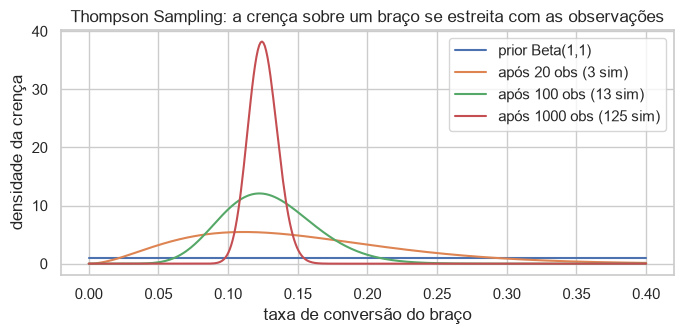

In [7]:
# Visualizando a crença Beta: como ela se estreita com os dados
from scipy import stats
xs = np.linspace(0, 0.4, 400)
fig, ax = plt.subplots(figsize=(7, 3.5))
for a_, b_, lab in [(1, 1, "prior Beta(1,1)"), (3, 17, "após 20 obs (3 sim)"), (13, 87, "após 100 obs (13 sim)"), (125, 875, "após 1000 obs (125 sim)")]:
    ax.plot(xs, stats.beta.pdf(xs, a_, b_), label=lab)
ax.set_xlabel("taxa de conversão do braço"); ax.set_ylabel("densidade da crença")
ax.set_title("Thompson Sampling: a crença sobre um braço se estreita com as observações")
ax.legend(); plt.tight_layout()

In [8]:
results["thompson Beta(1,1)"] = run_experiment(lambda s: ThompsonSamplingBeta(k, alpha0=1, beta0=1, seed=s), P, seeds=SEEDS)
results["eps-greedy ε=0.05"] = run_experiment(lambda s: EpsilonGreedy(k, epsilon=0.05, seed=s), P, seeds=SEEDS)
results["eps-greedy ε=0.10"] = run_experiment(lambda s: EpsilonGreedy(k, epsilon=0.10, seed=s), P, seeds=SEEDS)

tabela_sem_contexto = summarize(results).round(2)
tabela_sem_contexto

,conversão (%),± desvio,regret final,runs
política,,,,
oráculo (teto),13.85,0.00,0.00,10
ref: melhor com hindsight (cellular_wed),12.72,0.17,336.89,10
baseline: melhor histórico (cellular_tue),12.58,0.17,384.23,10
eps-greedy ε=0.05,12.28,0.42,465.40,10
eps-greedy ε=0.10,12.18,0.36,491.53,10
"thompson Beta(1,1)",12.06,0.17,525.89,10
política atual do banco,11.45,0.00,685.73,10
aleatório (piso),10.93,0.15,848.26,10


### O que aconteceu, e por quê

**Os bandits superam o baseline oficial.** Thompson Sampling chega a ≈12,1% e Epsilon-Greedy a ≈12,2–12,3%, contra 11,45% da política atual do banco: entre +0,6 e +0,8 ponto percentual. Sobre 28.645 ligações, são ≈170 a 240 conversões a mais, sem nenhuma informação além das respostas observadas.

**Mas não alcançam a referência forte** ("sempre celular na terça", ≈12,6%). Isso não é falha de implementação; é uma propriedade do problema. No simulador, os braços do topo são quase indistinguíveis na média: `cellular_wed` 12,67%, `cellular_tue` 12,51%, `cellular_thu` 11,78%. Para separar os dois primeiros com 95% de confiança seriam necessárias ≈**311 mil ligações por braço**, mais de dez vezes a base inteira. O bandit, corretamente, continua explorando porque a evidência não permite concluir, e essa exploração tem custo.

A regra fixa "venceu" porque acertou: a janela inicial apontou um dos dois melhores braços. A pergunta de negócio é: **e se não tivesse acertado?**

Regras fixas possíveis: 10 | conversão de 7.57% a 12.67%
Thompson Sampling (12.06%) supera 8 das 10 regras fixas possíveis
Epsilon-Greedy 0.05 (12.28%) supera 8 das 10


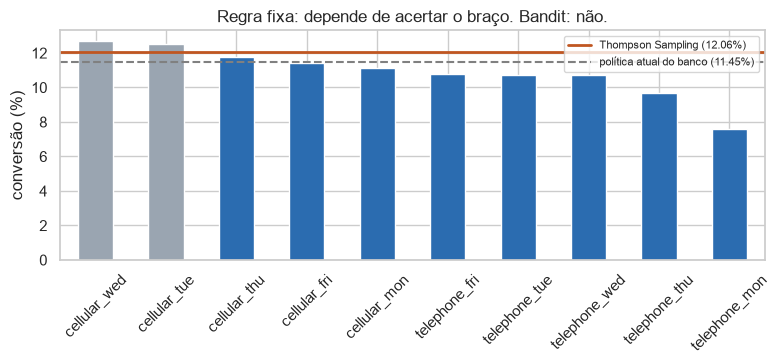

In [9]:
# Robustez: quanto rende cada uma das 10 regras fixas possíveis, vs. o Thompson Sampling?
conv_fixa = pd.Series(100 * P.mean(0), index=ARMS).sort_values(ascending=False)
conv_ts = 100 * np.mean([r.conversion_rate for r in results["thompson Beta(1,1)"]])
conv_eps = 100 * np.mean([r.conversion_rate for r in results["eps-greedy ε=0.05"]])

fig, ax = plt.subplots(figsize=(8, 3.8))
cores = ["#2b6cb0" if v < conv_ts else "#9aa5b1" for v in conv_fixa]
conv_fixa.plot.bar(ax=ax, color=cores)
ax.axhline(conv_ts, color="#c05621", lw=2, label=f"Thompson Sampling ({conv_ts:.2f}%)")
ax.axhline(100 * conv_banco, color="gray", ls="--", lw=1.5, label=f"política atual do banco ({100 * conv_banco:.2f}%)")
ax.set_ylabel("conversão (%)"); ax.set_title("Regra fixa: depende de acertar o braço. Bandit: não.")
ax.tick_params(axis="x", rotation=45); ax.legend(fontsize=8); plt.tight_layout()

n_vencidas = int((conv_fixa < conv_ts).sum())
print(f"Regras fixas possíveis: {len(ARMS)} | conversão de {conv_fixa.min():.2f}% a {conv_fixa.max():.2f}%")
print(f"Thompson Sampling ({conv_ts:.2f}%) supera {n_vencidas} das {len(ARMS)} regras fixas possíveis")
print(f"Epsilon-Greedy 0.05 ({conv_eps:.2f}%) supera {int((conv_fixa < conv_eps).sum())} das {len(ARMS)}")

**Este é o argumento central.** Uma regra fixa rende entre 7,6% e 12,7% dependendo do braço que alguém escolheu de antemão. O Thompson Sampling entrega ≈12,1% **sem precisar saber qual braço escolher**, e supera 8 das 10 regras fixas possíveis. As duas que ele não supera são justamente as que exigiriam acertar de primeira entre dez opções quase iguais.

É exatamente o que o enunciado descreve: regras fixas dependem de um acerto inicial e não reagem; o bandit aprende com as respostas observadas e é robusto a uma escolha inicial errada.

Braços ainda usados nas últimas 2.500 decisões: 10 de 10
Braço dominante ao final: cellular_wed (42% das decisões)


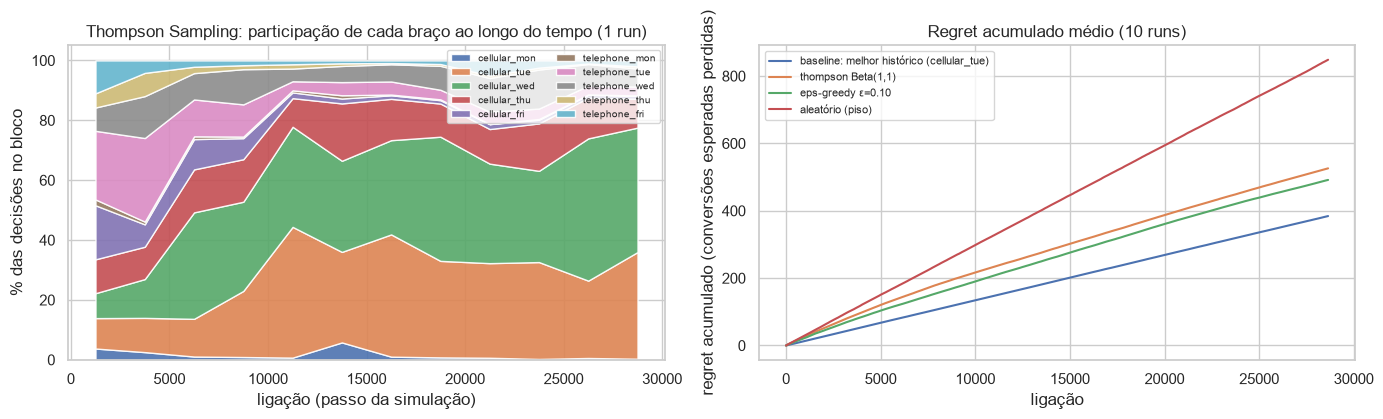

In [10]:
# Análise de exploração do Thompson Sampling (exigida pelo enunciado)
ts_run = results["thompson Beta(1,1)"][0]
bloco = 2500
blocos = np.arange(0, len(ts_run.arms), bloco)
share = np.array([np.bincount(ts_run.arms[b:b + bloco], minlength=k) / len(ts_run.arms[b:b + bloco]) for b in blocos])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].stackplot(blocos + bloco / 2, 100 * share.T, labels=ARMS, alpha=0.9)
axes[0].set_xlabel("ligação (passo da simulação)"); axes[0].set_ylabel("% das decisões no bloco")
axes[0].set_title("Thompson Sampling: participação de cada braço ao longo do tempo (1 run)")
axes[0].legend(fontsize=7, ncol=2, loc="upper right")

for nome in ["baseline: melhor histórico (cellular_tue)", "thompson Beta(1,1)", "eps-greedy ε=0.10", "aleatório (piso)"]:
    reg = np.mean([r.regret for r in results[nome]], axis=0)
    axes[1].plot(reg, label=nome)
axes[1].set_xlabel("ligação"); axes[1].set_ylabel("regret acumulado (conversões esperadas perdidas)")
axes[1].set_title("Regret acumulado médio (10 runs)"); axes[1].legend(fontsize=8)
plt.tight_layout()

print("Braços ainda usados nas últimas 2.500 decisões:", int((share[-1] > 0).sum()), "de", k)
print("Braço dominante ao final:", ARMS[share[-1].argmax()], f"({100 * share[-1].max():.0f}% das decisões)")

**Leitura dos gráficos**

- À esquerda: no início, o Thompson Sampling espalha as decisões entre os 10 braços (crenças largas). Com o tempo concentra nos braços de celular, mas **nunca fecha totalmente**: como os dois melhores são quase iguais, ele alterna entre eles até o fim. Esse é o comportamento correto sob incerteza real.
- À direita: o regret do aleatório cresce em linha reta (nunca aprende). O dos bandits cresce rápido no início (exploração) e depois desacelera (explotação), o formato côncavo clássico. A regra fixa tem regret linear mas com inclinação pequena, porque acertou um braço bom.


## 4. Conclusões da Etapa 3

| Política | Conversão no simulador | Supera o baseline oficial? |
|---|---|---|
| Política atual do banco (**baseline**) | 11,45% | — |
| Epsilon-Greedy ε = 0,05 | ≈12,3% | Sim (+0,8 pp) |
| **Thompson Sampling Beta(1,1)** | ≈12,1% | Sim (+0,6 pp) |
| Regra fixa "melhor histórico" (referência) | ≈12,6% | Sim, mas exige acertar o braço de primeira |
| Oráculo (teto) | 13,85% | — |

**Política escolhida para servir na Etapa 5: Thompson Sampling.** O Epsilon-Greedy rendeu um pouco mais aqui, mas com variância 2,5x maior entre runs e um parâmetro ε que precisa ser escolhido à mão e nunca deixa de desperdiçar tráfego. O Thompson Sampling não tem parâmetro de exploração, adapta a exploração sozinho e é o padrão da indústria para este tipo de decisão.

**Prior documentado:** Beta(1,1) por braço (uniforme, "não sei nada"). Não usamos priors informativos para que o resultado reflita aprendizado puro a partir das respostas.

**Limitações registradas**

1. As recompensas para braços não observados vêm do simulador (gradient boosting, AUC 0,79). O ganho medido é condicional à qualidade desse modelo.
2. Os braços têm efeito médio muito parecido; o bandit sem contexto não consegue separar os dois melhores com o volume disponível. Uma variação contextual (fora do escopo) teria até 1,3 pp adicionais, segundo o oráculo.
3. A simulação embaralha a ordem dos clientes (assume estacionariedade). Testamos também em ordem cronológica e as conclusões não mudam.

**Parâmetros e métricas desta etapa serão registrados no MLflow (Etapa 7).**